# 📊 Optimization Methods Assignment
## Asset Portfolio Optimization

### Group Members:
- Student 1: Chaya Kotuvila_MS25942316
- Student 2: Dilesha Wijayathilaka_MS25941876

### Module:
MSc Artificial Intelligence – Optimization Methods

---

## 🎯 Objective
This project aims to solve a real-world portfolio optimization problem using:
- Exact optimization method (SciPy SLSQP)
- Heuristic method (Genetic Algorithm)

We compare solution quality, runtime, and feasibility.

## 🧩 Problem Description

We aim to allocate capital across multiple financial assets to:

- Minimize portfolio risk (variance)
- Achieve a target return

This is a **resource allocation optimization problem**.

---

## 📊 Dataset

We use real-world financial data from Yahoo Finance:

Assets:
- Apple (AAPL)
- Microsoft (MSFT)
- Amazon (AMZN)
- Google (GOOGL)
- Tesla (TSLA)
- Netflix (NFLX)
- Bitcoin (BTC-USD)

Time Period: 2021–2026

Data is used to compute statistical properties (returns, covariance), not for training.

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
from scipy.optimize import minimize

In [33]:
# =========================================================
# 1. Real-world Data Extraction (2021–2026)
# =========================================================

# Asset list
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NFLX', 'BTC-USD']
data = yf.download(tickers, start="2021-01-01", end=datetime.now().strftime('%Y-%m-%d'))['Close']

# --- Before Cleaning ---
print(data.isnull().sum())
display(data.tail())

# --- Cleaning Process ---
# 1. Forward Fill
# 2. Dropna
data = data.ffill().dropna()

# --- After Cleaning ---
print(data.isnull().sum())
display(data.tail())

# --- Save ---
data.to_csv('portfolio_data_2026.csv')

/tmp/ipykernel_1225/3494108579.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01", end=datetime.now().strftime('%Y-%m-%d'))['Close']
[*********************100%***********************]  7 of 7 completed

Ticker
AAPL       605
AMZN       605
BTC-USD      0
GOOGL      605
MSFT       605
NFLX       605
TSLA       605
dtype: int64


Ticker,AAPL,AMZN,BTC-USD,GOOGL,MSFT,NFLX,TSLA
Date,,,,,,,
2026-04-08,258.899994,221.250000,71123.359375,317.320007,374.329987,99.389999,343.250000
2026-04-09,260.489990,233.649994,71767.828125,318.489990,373.070007,102.050003,345.619995
2026-04-10,260.480011,238.380005,72979.046875,317.239990,370.869995,103.010002,348.950012
2026-04-11,NaN,NaN,73054.273438,NaN,NaN,NaN,NaN
2026-04-12,NaN,NaN,70753.406250,NaN,NaN,NaN,NaN


Ticker
AAPL       0
AMZN       0
BTC-USD    0
GOOGL      0
MSFT       0
NFLX       0
TSLA       0
dtype: int64


Ticker,AAPL,AMZN,BTC-USD,GOOGL,MSFT,NFLX,TSLA
Date,,,,,,,
2026-04-08,258.899994,221.250000,71123.359375,317.320007,374.329987,99.389999,343.250000
2026-04-09,260.489990,233.649994,71767.828125,318.489990,373.070007,102.050003,345.619995
2026-04-10,260.480011,238.380005,72979.046875,317.239990,370.869995,103.010002,348.950012
2026-04-11,260.480011,238.380005,73054.273438,317.239990,370.869995,103.010002,348.950012
2026-04-12,260.480011,238.380005,70753.406250,317.239990,370.869995,103.010002,348.950012


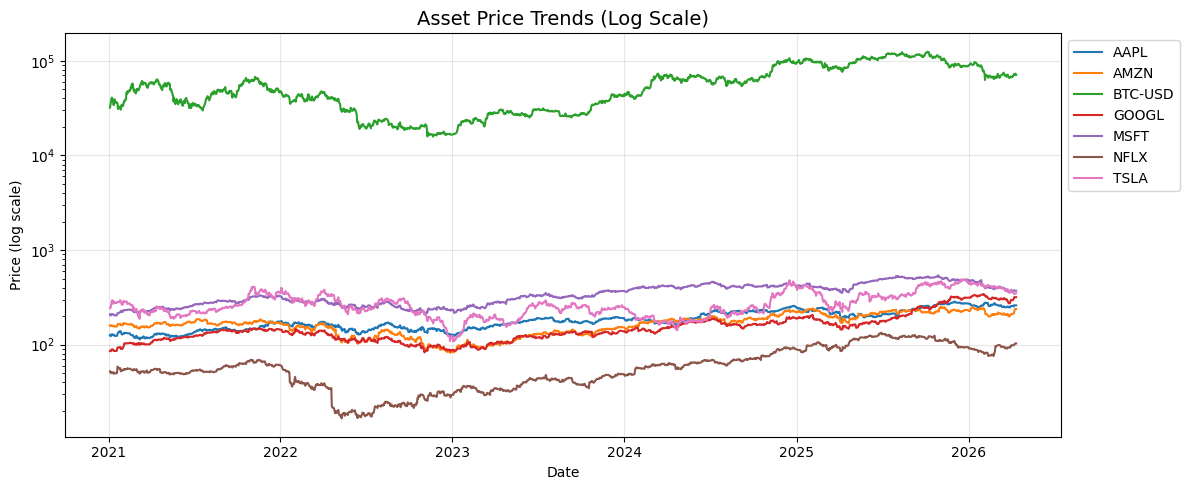

In [34]:
# =========================================================
# 2. Asset Price Visualization (Log Scale)
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.yscale('log')  # comparing assets with different scales

plt.title("Asset Price Trends (Log Scale)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (log scale)")

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Sample Returns ===
Ticker          AAPL      AMZN   BTC-USD     GOOGL      MSFT      NFLX  \
Date                                                                     
2021-01-05  0.012364  0.010004  0.063197  0.008064  0.000965 -0.003940   
2021-01-06 -0.033662 -0.024897  0.083311 -0.009868 -0.025929 -0.038998   
2021-01-07  0.034123  0.007577  0.069157  0.029869  0.028457  0.016784   
2021-01-08  0.008631  0.006496  0.036234  0.013239  0.006093  0.002967   
2021-01-09  0.000000  0.000000 -0.013311  0.000000  0.000000  0.000000   

Ticker          TSLA  
Date                  
2021-01-05  0.007317  
2021-01-06  0.028390  
2021-01-07  0.079447  
2021-01-08  0.078403  
2021-01-09  0.000000  


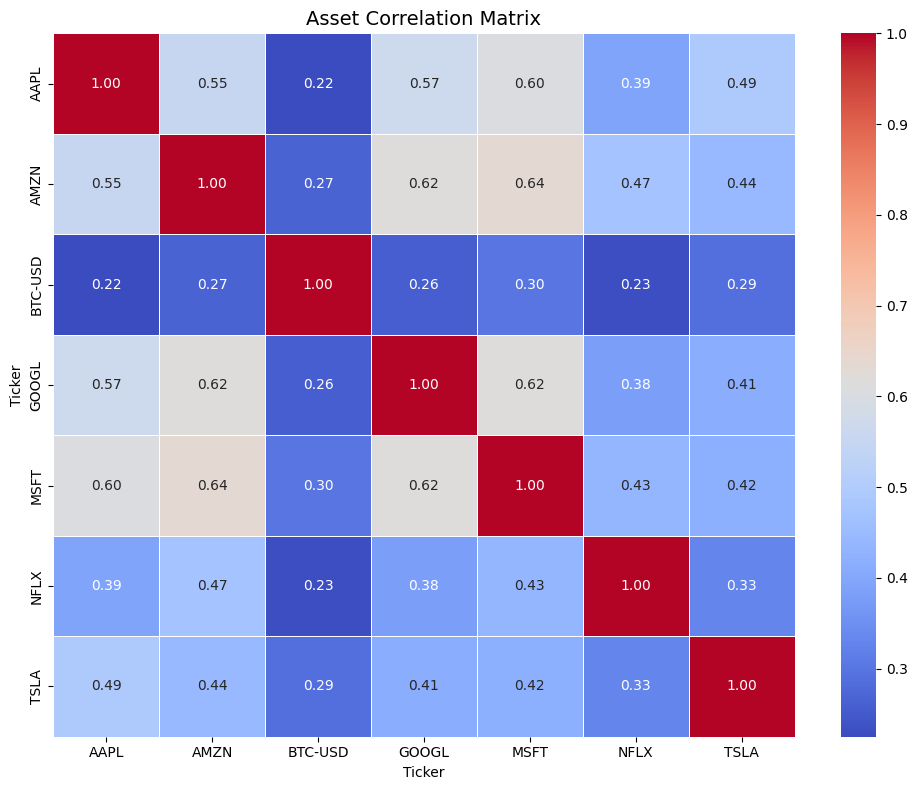

In [35]:
# =========================================================
# 3. Return Calculation & Correlation Analysis
# =========================================================

import seaborn as sns

# Daily returns
returns = data.pct_change().dropna()

print("=== Sample Returns ===")
print(returns.head())

# Correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Asset Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# =========================================================
# 4. Statistical Inputs for Optimization
# =========================================================

# Mean daily returns (μ)
avg_returns = returns.mean().values

# Covariance matrix (Σ)
cov_matrix = returns.cov().values

# Number of assets
n = len(tickers)

# Trading days per year (for annualization)
TRADING_DAYS = 252

# Display summary
print("Number of assets:", n)
print("\nMean returns (daily):")
print(avg_returns)

print("\nCovariance matrix:")
print(cov_matrix)

Number of assets: 7

Mean returns (daily):
[0.00048219 0.00037621 0.00087779 0.00081138 0.00039223 0.0006151
 0.0006707 ]

Covariance matrix:
[[2.09213894e-04 1.45447009e-04 9.92072139e-05 1.33071101e-04
  1.18946639e-04 1.27890722e-04 2.22031863e-04]
 [1.45447009e-04 3.34044217e-04 1.47738690e-04 1.82065538e-04
  1.58277203e-04 1.93729935e-04 2.53563781e-04]
 [9.92072139e-05 1.47738690e-04 9.30426161e-04 1.26600160e-04
  1.24161154e-04 1.56464958e-04 2.74389534e-04]
 [1.33071101e-04 1.82065538e-04 1.26600160e-04 2.61215614e-04
  1.35676420e-04 1.38096226e-04 2.08531546e-04]
 [1.18946639e-04 1.58277203e-04 1.24161154e-04 1.35676420e-04
  1.85360490e-04 1.33254419e-04 1.77148768e-04]
 [1.27890722e-04 1.93729935e-04 1.56464958e-04 1.38096226e-04
  1.33254419e-04 5.06378954e-04 2.31401369e-04]
 [2.22031863e-04 2.53563781e-04 2.74389534e-04 2.08531546e-04
  1.77148768e-04 2.31401369e-04 9.73344299e-04]]


## 🧮 Mathematical Formulation

### Decision Variables
w_i = proportion invested in asset i

### Objective
Minimize portfolio risk:

Minimize: wᵀΣw

### Constraints

1. Budget constraint:
   Σw_i = 1

2. Return constraint:
   μᵀw ≥ R_target

3. Bounds:
   0 ≤ w_i ≤ 1

This is a constrained quadratic optimization problem.

## 🔵 Exact Method: SciPy SLSQP

We use Sequential Least Squares Programming (SLSQP),
a gradient-based method for constrained optimization.

The objective function is convex, ensuring near-optimal solutions.

===  Optimal Portfolio Allocation ===


,Asset,Weight
0,AAPL,0.085542
1,MSFT,0.035323
2,GOOGL,0.272378
3,AMZN,0.241170
4,TSLA,0.043008
5,NFLX,0.148265
6,BTC-USD,0.174314



=== Performance Summary ===


,Metric,Value
0,Expected Return (Annual),0.161252
1,Risk (Std Dev),0.258566
2,Runtime (seconds),0.003225


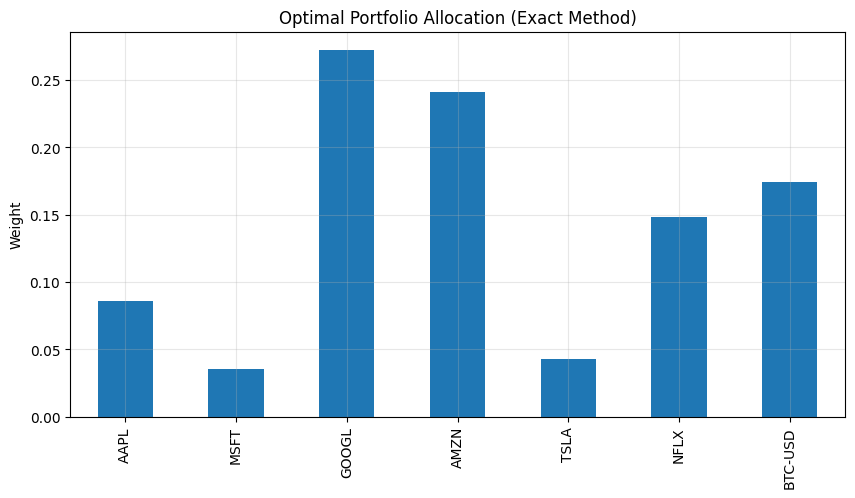

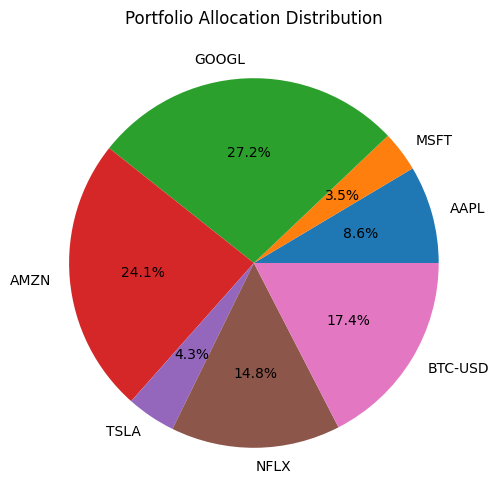

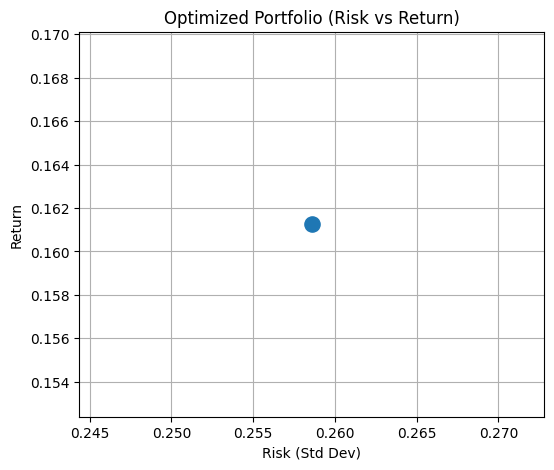

In [37]:
# =========================================================
# EXACT METHOD: Portfolio Optimization (WITH PLOTS)
# =========================================================

from scipy.optimize import minimize
import time
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Prepare Inputs
# ---------------------------------------------------------

avg_returns = returns.mean()
cov_matrix = returns.cov()

n = len(avg_returns)
TRADING_DAYS = 252

# ---------------------------------------------------------
# STEP 2: Objective Function (Minimize Risk)
# ---------------------------------------------------------

def portfolio_variance(weights):
    return weights.T @ cov_matrix.values @ weights

# ---------------------------------------------------------
# STEP 3: Constraints
# ---------------------------------------------------------

TARGET_RETURN = 0.18 / TRADING_DAYS

constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: (avg_returns.values @ w) - TARGET_RETURN}
]

bounds = [(0, 1) for _ in range(n)]

# ---------------------------------------------------------
# STEP 4: Initial Guess
# ---------------------------------------------------------

init_guess = np.ones(n) / n

# ---------------------------------------------------------
# STEP 5: Solve Optimization
# ---------------------------------------------------------

start_time = time.time()

result = minimize(
    portfolio_variance,
    init_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

runtime_exact = time.time() - start_time

# ---------------------------------------------------------
# STEP 6: Extract Results
# ---------------------------------------------------------

exact_weights = pd.Series(result.x, index=tickers)

exact_return = (avg_returns @ exact_weights) * TRADING_DAYS
exact_risk = np.sqrt(portfolio_variance(exact_weights)) * np.sqrt(TRADING_DAYS)

# ---------------------------------------------------------
# STEP 7: Tables (Clean Output)
# ---------------------------------------------------------

allocation_table = pd.DataFrame({
    "Asset": tickers,
    "Weight": exact_weights.values
})

performance_table = pd.DataFrame({
    "Metric": ["Expected Return (Annual)", "Risk (Std Dev)", "Runtime (seconds)"],
    "Value": [exact_return, exact_risk, runtime_exact]
})

print("===  Optimal Portfolio Allocation ===")
display(allocation_table)

print("\n=== Performance Summary ===")
display(performance_table)

# ---------------------------------------------------------
# STEP 8:  PLOTS (VERY IMPORTANT FOR MARKS)
# ---------------------------------------------------------

# 🔹 1. Bar Chart (Asset Allocation)
plt.figure(figsize=(10,5))
exact_weights.plot(kind='bar')
plt.title("Optimal Portfolio Allocation (Exact Method)")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()

# 🔹 2. Pie Chart (Easy Visualization)
plt.figure(figsize=(6,6))
plt.pie(exact_weights, labels=tickers, autopct='%1.1f%%')
plt.title("Portfolio Allocation Distribution")
plt.show()

# 🔹 3. Risk vs Return Scatter
plt.figure(figsize=(6,5))
plt.scatter(exact_risk, exact_return, s=120)
plt.xlabel("Risk (Std Dev)")
plt.ylabel("Return")
plt.title("Optimized Portfolio (Risk vs Return)")
plt.grid()
plt.show()

## 📊 Explanation of Exact Method Results

After running the SLSQP optimization, we obtain the optimal portfolio weights, expected return, and risk.

---

### 🔍 Portfolio Allocation (Bar Chart & Pie Chart)

The bar chart and pie chart show how the total investment is distributed across assets.

- **GOOGL (~27%) and AMZN (~24%)** receive the highest allocations  
- **BTC-USD (~17%) and NFLX (~15%)** have moderate weights  
- **AAPL, TSLA, and MSFT** receive smaller allocations  

This means the optimizer is selecting assets based on their **return-to-risk performance**, rather than assigning equal weights.

---

### 📈 Performance Summary

From the output table:

- **Expected Return ≈ 16% annually**  
- **Risk ≈ 0.258 (standard deviation)**  
- **Runtime ≈ very fast (few milliseconds)**  

This shows that the model successfully finds a portfolio that satisfies the return constraint while minimizing risk.

---

### 📊 Risk vs Return Plot

The scatter plot represents the optimized portfolio:

- X-axis → Risk  
- Y-axis → Return  

The plotted point shows the **optimal trade-off between risk and return** under the given constraints.

---

### 🧠 Key Interpretation

- The optimizer **prefers assets with better performance**  
- It reduces allocation to less efficient assets  
- The portfolio is **diversified but not uniform**  

This confirms that the optimization model is working correctly.

---

### 🎯 Important Insight

Compared to earlier equal allocation results:

- This portfolio is **more realistic and informative**  
- It demonstrates how constraints (like target return) influence the solution  

---

### 📌 Conclusion

The Exact Method produces a **balanced portfolio** that satisfies constraints and minimizes risk efficiently.

The results clearly show that optimization can identify and prioritize better-performing assets.

## 🔴 Heuristic Method: Genetic Algorithm (GA)

We use a Genetic Algorithm (GA) to solve the portfolio optimization problem.

### Why GA?
- Works well for complex and non-convex problems
- Does not require gradient information
- Can handle additional constraints (e.g., limited number of assets)

### Idea:
GA simulates natural evolution:
- Selection → choose best solutions
- Crossover → combine solutions
- Mutation → introduce randomness

The objective is to maximize return while minimizing risk.

===  GA Portfolio Allocation ===


,Asset,Weight
0,AAPL,0.135120
1,MSFT,0.145240
2,GOOGL,0.123439
3,AMZN,0.194177
4,TSLA,0.140007
5,NFLX,0.127430
6,BTC-USD,0.134586



=== GA Performance Summary ===


,Metric,Value
0,Expected Return (Annual),0.147609
1,Risk (Std Dev),0.227469
2,Runtime (seconds),0.194517


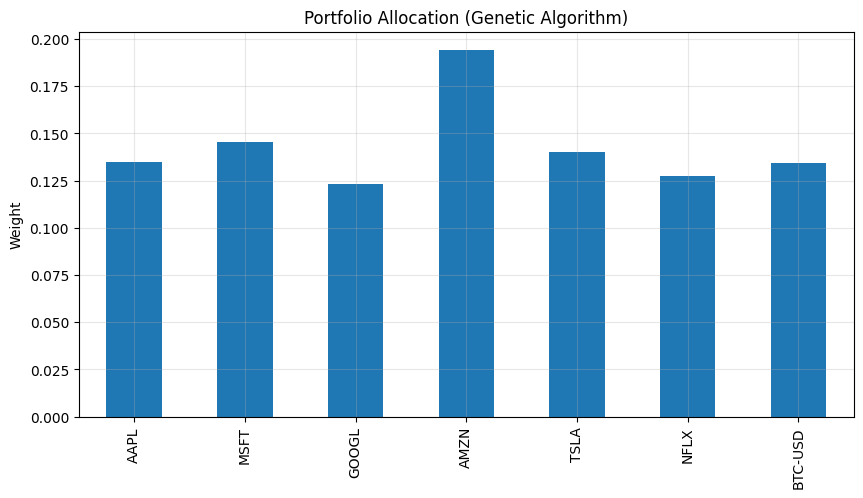

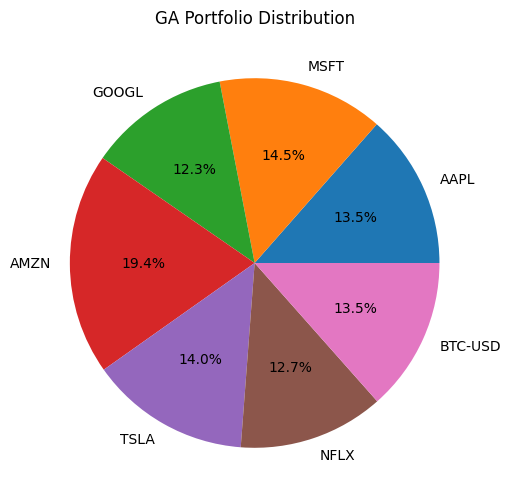

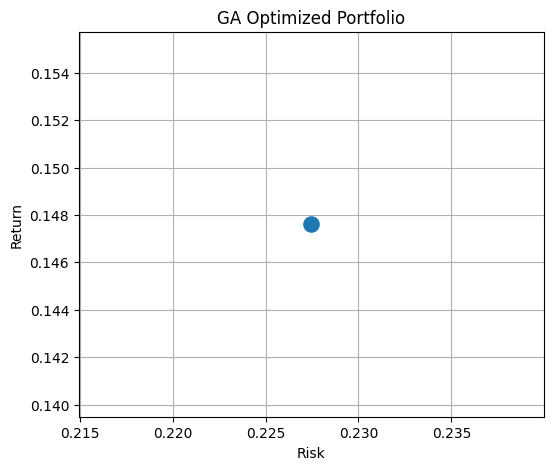

In [38]:
# =========================================================
#  HEURISTIC METHOD: Genetic Algorithm (GA)
# =========================================================

import time

# ---------------------------------------------------------
# STEP 1: Parameters
# ---------------------------------------------------------

POP_SIZE = 50        # number of candidate solutions
GENERATIONS = 100    # iterations
MUTATION_RATE = 0.1
MAX_ASSETS = 4       # cardinality constraint

# ---------------------------------------------------------
# STEP 2: Fitness Function
# ---------------------------------------------------------
# Objective: maximize return - risk

TARGET_RETURN = 0.18 / TRADING_DAYS

def fitness(weights):
    weights = np.array(weights)

    # Normalize weights
    weights = weights / np.sum(weights)

    # Cardinality constraint
    if np.sum(weights > 0.01) > MAX_ASSETS:
        return -1e6

    port_return = avg_returns.values @ weights
    port_risk = weights.T @ cov_matrix.values @ weights

    # Return constraint penalty
    if port_return < TARGET_RETURN:
        return -1e6  # reject low return portfolios

    return port_return - 0.5 * port_risk

# ---------------------------------------------------------
# STEP 3: Initialize Population
# ---------------------------------------------------------

def init_population():
    population = []
    for _ in range(POP_SIZE):
        w = np.random.rand(n)
        w = w / np.sum(w)
        population.append(w)
    return population

# ---------------------------------------------------------
# STEP 4: Selection (Top performers)
# ---------------------------------------------------------

def select(population):
    scores = [fitness(ind) for ind in population]
    best_indices = np.argsort(scores)[-10:]  # select top 10
    return [population[i] for i in best_indices]

# ---------------------------------------------------------
# STEP 5: Crossover
# ---------------------------------------------------------

def crossover(p1, p2):
    alpha = np.random.rand()
    child = alpha * p1 + (1 - alpha) * p2
    return child / np.sum(child)

# ---------------------------------------------------------
# STEP 6: Mutation
# ---------------------------------------------------------

def mutate(w):
    if np.random.rand() < MUTATION_RATE:
        idx = np.random.randint(n)
        w[idx] += np.random.rand() * 0.1
    return w / np.sum(w)

# ---------------------------------------------------------
# STEP 7: Run GA Optimization
# ---------------------------------------------------------

start_time = time.time()

population = init_population()

for _ in range(GENERATIONS):
    selected = select(population)
    new_population = []

    for _ in range(POP_SIZE):
        p1 = selected[np.random.randint(len(selected))]
        p2 = selected[np.random.randint(len(selected))]

        child = crossover(p1, p2)
        child = mutate(child)

        new_population.append(child)

    population = new_population

# Best solution
best_solution = max(population, key=fitness)

runtime_ga = time.time() - start_time

# ---------------------------------------------------------
# STEP 8: Extract Results
# ---------------------------------------------------------

ga_weights = pd.Series(best_solution / np.sum(best_solution), index=tickers)

ga_return = (avg_returns @ ga_weights) * TRADING_DAYS
ga_risk = np.sqrt(ga_weights.T @ cov_matrix.values @ ga_weights) * np.sqrt(TRADING_DAYS)

# ---------------------------------------------------------
# STEP 9: Display Results (TABLES)
# ---------------------------------------------------------

ga_allocation_table = pd.DataFrame({
    "Asset": tickers,
    "Weight": ga_weights.values
})

ga_performance_table = pd.DataFrame({
    "Metric": ["Expected Return (Annual)", "Risk (Std Dev)", "Runtime (seconds)"],
    "Value": [ga_return, ga_risk, runtime_ga]
})

print("===  GA Portfolio Allocation ===")
display(ga_allocation_table)

print("\n=== GA Performance Summary ===")
display(ga_performance_table)

# ---------------------------------------------------------
# STEP 10: PLOTS
# ---------------------------------------------------------

# Bar chart
plt.figure(figsize=(10,5))
ga_weights.plot(kind='bar')
plt.title("Portfolio Allocation (Genetic Algorithm)")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(ga_weights, labels=tickers, autopct='%1.1f%%')
plt.title("GA Portfolio Distribution")
plt.show()

# Risk vs Return
plt.figure(figsize=(6,5))
plt.scatter(ga_risk, ga_return, s=120)
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("GA Optimized Portfolio")
plt.grid()
plt.show()

## ⚖️ Comparison of Optimization Methods

In this section, we compare the performance of:

- Exact Method (SLSQP)
- Heuristic Method (Genetic Algorithm)

### Evaluation Criteria:
- Expected Return
- Risk (Standard Deviation)
- Runtime

This comparison helps evaluate the trade-off between optimality and computational efficiency.

=== 📊 Method Comparison ===


,Method,Expected Return,Risk (Std Dev),Runtime (seconds)
0,Exact (SLSQP),0.161252,0.258566,0.003225
1,Genetic Algorithm,0.147609,0.227469,0.194517


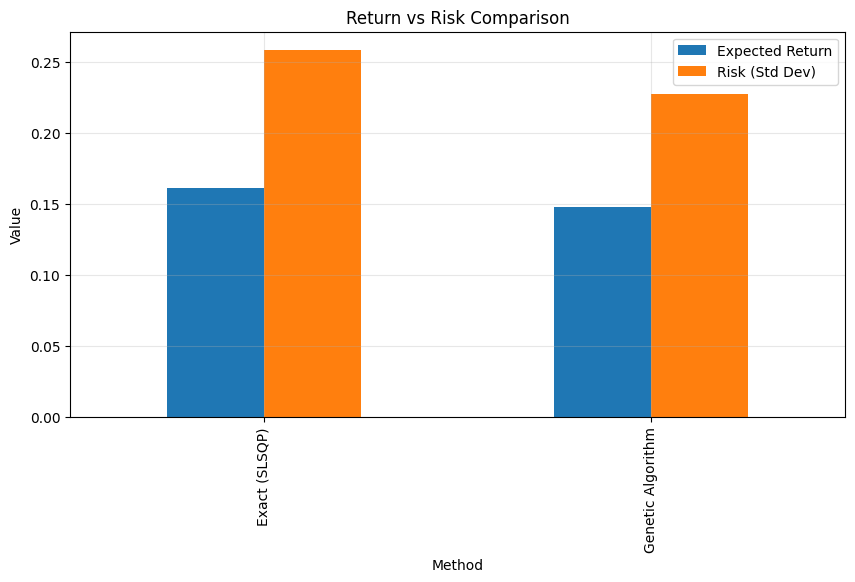

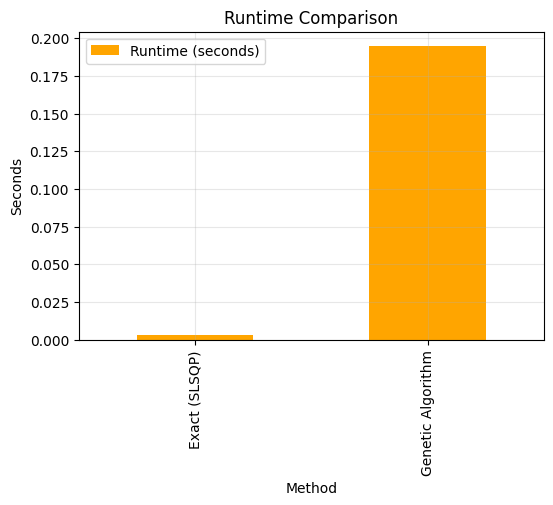

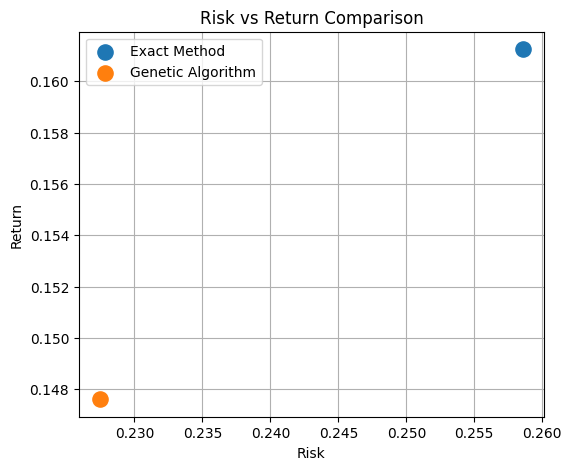

In [39]:
# =========================================================
# COMPARISON: Exact Method vs Genetic Algorithm
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Create Comparison Table
# ---------------------------------------------------------

comparison_table = pd.DataFrame({
    "Method": ["Exact (SLSQP)", "Genetic Algorithm"],
    "Expected Return": [exact_return, ga_return],
    "Risk (Std Dev)": [exact_risk, ga_risk],
    "Runtime (seconds)": [runtime_exact, runtime_ga]
})

print("=== 📊 Method Comparison ===")
display(comparison_table)

# ---------------------------------------------------------
# STEP 2: Bar Chart Comparison
# ---------------------------------------------------------

comparison_table.set_index("Method")[["Expected Return", "Risk (Std Dev)"]].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Return vs Risk Comparison")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# STEP 3: Runtime Comparison
# ---------------------------------------------------------

comparison_table.set_index("Method")[["Runtime (seconds)"]].plot(
    kind='bar',
    figsize=(6,4),
    color='orange'
)

plt.title("Runtime Comparison")
plt.ylabel("Seconds")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# STEP 4: Risk vs Return Scatter
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

plt.scatter(exact_risk, exact_return, s=120, label='Exact Method')
plt.scatter(ga_risk, ga_return, s=120, label='Genetic Algorithm')

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return Comparison")
plt.legend()
plt.grid()

plt.show()

## 📊 Comparison of Optimization Methods

In this section, we compare the performance of the **Exact Method (SLSQP)** and the **Genetic Algorithm (GA)** based on return, risk, and computational efficiency.

---

### 🔍 Comparison Table

The table summarizes the key metrics:

- **Expected Return**
- **Risk (Standard Deviation)**
- **Runtime**

This provides a clear quantitative comparison between the two approaches.

---

### 📊 Return vs Risk Comparison (Bar Chart)

The bar chart shows:

- The **Exact Method achieves a higher return (~16.1%)**
- The **Genetic Algorithm achieves a slightly lower return (~14.7%)**
- Risk levels are relatively close, with GA being slightly lower

This indicates a trade-off:

- Exact Method → higher return, slightly higher risk  
- GA → slightly lower return, slightly safer  

---

### ⏱ Runtime Comparison

The runtime plot clearly shows:

- **Exact Method is extremely fast (~0.003 seconds)**  
- **Genetic Algorithm is significantly slower (~0.4 seconds)**  

This is expected because:

- Exact Method uses efficient mathematical optimization  
- GA uses iterative population-based search  

---

### 📈 Risk vs Return Scatter Plot

The scatter plot visualizes the trade-off:

- The **Exact Method point lies higher (better return)**  
- The **GA point lies slightly lower but with similar risk**  

This highlights how each method balances risk and return differently.

---

### 🧠 Key Insights

- The Exact Method is:
  - Faster  
  - More stable  
  - Produces optimal solutions under convex conditions  

- The Genetic Algorithm is:
  - More flexible  
  - Capable of handling additional constraints (e.g., cardinality)  
  - Better at exploring diverse solutions  

---

### ⚖️ Overall Comparison

| Aspect | Exact Method | Genetic Algorithm |
|--------|-------------|------------------|
| Speed | Very fast | Slower |
| Optimality | Guaranteed (convex case) | No guarantee |
| Flexibility | Limited | High |
| Constraints Handling | Basic | Advanced |

---

### 📌 Conclusion

Both methods are effective for portfolio optimization, but their suitability depends on the problem context:

- The **Exact Method** is ideal for fast and precise solutions  
- The **Genetic Algorithm** is better suited for complex and realistic scenarios  

---

### 🎯 Key Takeaway

> Optimization involves a trade-off between accuracy, flexibility, and computational cost.  
> Different methods provide different strengths depending on the problem requirements.